# Desafio

A empresa Você Mais Seguro fornece planos de saúde e seguros de vida. 
A empresa está interessada em lança um novo seguro de veiculos, e desja entender a propensão de compra de seus clientes para este novo cenário. 
Em uma primeira etapa, foi realizada uma grande pesquisa com seus cleintes, para entender quais destes clientes estariam interessados em adquirir o novo seguro de veiculos.

Agora, com novos clientes do plano de saude entrando para sua base, a empresa deseja entender quais destes novos clientes teriam maior propensão de compra do novo seguro de veiculos.
No entanto, a empresa não esta interessada em gastar com pesquisas para todos os novos clientes, e sim apenas para aqueles que tem maior propensão de compra, 
haja visto,que seu efetivo comercial, não é capaz de entrar em contato, para fornecer um processo de pré vendas personalizado para toda a base de seus novos clientes, somente
para 2000 deles de cada vez. 

Para isso, este projeto tem como objetivo apresentar uma lista, com os 2000 clientes com maior probabilidade de venda do seguro de veículos.

# 0.0 Imports

In [1]:
import pandas as pd 
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier 


### 0.1 Helper Functions

In [2]:
def jupyter_settings():
    %matplotlib inline
    %pylab inline

    plt.style.use( 'bmh' )
    plt.rcParams['figure.figsize'] = [25, 8]
    plt.rcParams['font.size'] = 24
    pd.options.display.max_columns = None
    pd.options.display.max_rows = None
    pd.set_option( 'display.expand_frame_repr', False )
    sns.set()

jupyter_settings()

def print_descriptive_stats(df,
                            column):
    print(f'**Clientes que adquiririam o Seguro - {column} statistics**')
    print(df[df.Response == 1][column].describe())
    print('-'*45)
    print(f'**Clientes NAO que adquiririam o Seguro - {column} statistics**')
    print(df[df.Response == 0][column].describe())
    print('\n')

def get_frequency_table(df, column): 

    df_frequency_1 = df[df.Response == 1].groupby(column).Response.count().reset_index()
    df_frequency_1.rename(columns={'Response':'Count_Response_1'}, inplace=True)


    df_frequency_0 = df[df.Response == 0].groupby(column).Response.count().reset_index()
    df_frequency_0.rename(columns={'Response':'Count_Response_0'}, inplace=True)

    df_frequency = pd.merge(df_frequency_1, df_frequency_0, on=column, how='inner') 
    df_frequency['Total'] = df_frequency['Count_Response_1'] + df_frequency['Count_Response_0']
    df_frequency['Propensity_to_buy'] = df_frequency['Count_Response_1']/df_frequency['Total']
    df_frequency['%_sample_to_buy'] = df_frequency['Count_Response_1']/df_frequency['Count_Response_1'].sum() 
    df_frequency['%_sample_to_not_buy'] = df_frequency['Count_Response_0']/df_frequency['Count_Response_0'].sum() 
    df_frequency['%_sample_size']   = df_frequency['Total']/len(df)
    df_frequency['%_general_propensity_to_buy'] = len(df[df.Response==1])/len(df)
    
    return df_frequency

def transform_pipeline(df):

    '''
    [EM FASE DE VALIDACAO....]
    '''
    from sklearn.preprocessing import StandardScaler, MinMaxScaler 


    region_code = df.Region_Code.copy()
    dummies_region_code = pd.get_dummies(region_code,prefix = "region_code")

    sales_channel = df.Policy_Sales_Channel.copy()
    dummies_sales_channel = pd.get_dummies(sales_channel,prefix = "policy_sales_channel")

    df_copy = df.copy()
    df_encoded = pd.concat([df_copy, dummies_sales_channel, dummies_region_code], axis = 1)

    df_encoded.loc[:,'Vehicle_Age'] = df_encoded.loc[:,'Vehicle_Age'].map({'< 1 Year':0, '1-2 Year':1, '> 2 Years':2})


    df_encoded.drop(columns = ['Region_Code','Policy_Sales_Channel'], inplace = True)

    map_sexo_feminino = {
        'Male' : 0,
        'Female' : 1 
    }

    df_encoded['sexo_feminino'] = df_encoded.Gender.map(map_sexo_feminino)


    df_encoded.Vehicle_Damage = df_encoded.Vehicle_Damage.map({
        'Yes' : 1,
        'No'  : 0
    })


    scaller_premium      = MinMaxScaler()
    scaller_vintage      = MinMaxScaler()
    scaller_age          = MinMaxScaler()
    scaller_faixa_etaria = MinMaxScaler()

    df_encoded.Vintage_Scalled        = scaller_vintage.fit_transform(df_encoded.Vintage.values.reshape(-1,1))
    df_encoded.Annual_Premium_Scalled = scaller_premium.fit_transform(df_encoded.Annual_Premium.values.reshape(-1,1))


    df_encoded.Age        = scaller_age.fit_transform(df_encoded.Age.values.reshape(-1,1))
    df_encoded.faixa_etaria        = scaller_faixa_etaria.fit_transform(df_encoded.faixa_etaria.values.reshape(-1,1))


    df_encoded.Annual_Premium.describe()

    df_to_model = df_encoded[[x for x in df_encoded.columns if x not in ['id','Vintage_months','Vintage_weeks','Vintage']]]

    return df_to_model

#df_to_model = transform_pipeline(df_raw)

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


# 1.0 Limpeza dos Dados

**Tipos de limpezas**

* Nulos
* Tipagem inconsistente 
* Claros outliers (indicio de erro de digitação)


### 1.1 - Conhecendo o Dataset

In [3]:
df_raw = pd.read_csv('../data/raw/data.csv')
df_raw.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


# 3.0 - Preparação dos dados

In [4]:
df_3 = df_raw.copy()
df_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


### 3.1 - Criação de features

* Faixa etaria
* Tem entre 30 - 50 anos (EDA)

In [5]:
df_3['faixa_etaria'] = df_3.Age.apply(lambda x: 10*(x//10))
df_3['entre_30_50'] = df_3.Age.apply(lambda x: 1 if (x>=30) and (x<=50) else 0)


### 3.1 - Encodings

#### 3.1.1 - One Hot Encoding (dummi)

* Policy Sales Channel 
* Region Code

**Region Code**

A justificativa se da pela ausencia de elação quantitativa nos dados de region code. 

A regiao "102" ser maior que a regiao "32" não faz sentido


In [6]:
region_code = df_3.Region_Code.copy()
dummies_region_code = pd.get_dummies(region_code,prefix = "region_code")
dummies_region_code.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 53 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   region_code_0.0   381109 non-null  bool 
 1   region_code_1.0   381109 non-null  bool 
 2   region_code_2.0   381109 non-null  bool 
 3   region_code_3.0   381109 non-null  bool 
 4   region_code_4.0   381109 non-null  bool 
 5   region_code_5.0   381109 non-null  bool 
 6   region_code_6.0   381109 non-null  bool 
 7   region_code_7.0   381109 non-null  bool 
 8   region_code_8.0   381109 non-null  bool 
 9   region_code_9.0   381109 non-null  bool 
 10  region_code_10.0  381109 non-null  bool 
 11  region_code_11.0  381109 non-null  bool 
 12  region_code_12.0  381109 non-null  bool 
 13  region_code_13.0  381109 non-null  bool 
 14  region_code_14.0  381109 non-null  bool 
 15  region_code_15.0  381109 non-null  bool 
 16  region_code_16.0  381109 non-null  bool 
 17  region_cod

**Policy Sales Channel**

In [7]:
sales_channel = df_3.Policy_Sales_Channel.copy()
dummies_sales_channel = pd.get_dummies(sales_channel,prefix = "policy_sales_channel")
dummies_sales_channel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Columns: 155 entries, policy_sales_channel_1.0 to policy_sales_channel_163.0
dtypes: bool(155)
memory usage: 56.3 MB


In [8]:
dummies_sales_channel.head(5)

,policy_sales_channel_1.0,policy_sales_channel_2.0,policy_sales_channel_3.0,policy_sales_channel_4.0,policy_sales_channel_6.0,policy_sales_channel_7.0,policy_sales_channel_8.0,policy_sales_channel_9.0,policy_sales_channel_10.0,policy_sales_channel_11.0,policy_sales_channel_12.0,policy_sales_channel_13.0,policy_sales_channel_14.0,policy_sales_channel_15.0,policy_sales_channel_16.0,policy_sales_channel_17.0,policy_sales_channel_18.0,policy_sales_channel_19.0,policy_sales_channel_20.0,policy_sales_channel_21.0,policy_sales_channel_22.0,policy_sales_channel_23.0,policy_sales_channel_24.0,policy_sales_channel_25.0,policy_sales_channel_26.0,policy_sales_channel_27.0,policy_sales_channel_28.0,policy_sales_channel_29.0,policy_sales_channel_30.0,policy_sales_channel_31.0,policy_sales_channel_32.0,policy_sales_channel_33.0,policy_sales_channel_34.0,policy_sales_channel_35.0,policy_sales_channel_36.0,policy_sales_channel_37.0,policy_sales_channel_38.0,policy_sales_channel_39.0,policy_sales_channel_40.0,policy_sales_channel_41.0,policy_sales_channel_42.0,policy_sales_channel_43.0,policy_sales_channel_44.0,policy_sales_channel_45.0,policy_sales_channel_46.0,policy_sales_channel_47.0,policy_sales_channel_48.0,policy_sales_channel_49.0,policy_sales_channel_50.0,policy_sales_channel_51.0,policy_sales_channel_52.0,policy_sales_channel_53.0,policy_sales_channel_54.0,policy_sales_channel_55.0,policy_sales_channel_56.0,policy_sales_channel_57.0,policy_sales_channel_58.0,policy_sales_channel_59.0,policy_sales_channel_60.0,policy_sales_channel_61.0,policy_sales_channel_62.0,policy_sales_channel_63.0,policy_sales_channel_64.0,policy_sales_channel_65.0,policy_sales_channel_66.0,policy_sales_channel_67.0,policy_sales_channel_68.0,policy_sales_channel_69.0,policy_sales_channel_70.0,policy_sales_channel_71.0,policy_sales_channel_73.0,policy_sales_channel_74.0,policy_sales_channel_75.0,policy_sales_channel_76.0,policy_sales_channel_78.0,policy_sales_channel_79.0,policy_sales_channel_80.0,policy_sales_channel_81.0,policy_sales_channel_82.0,policy_sales_channel_83.0,policy_sales_channel_84.0,policy_sales_channel_86.0,policy_sales_channel_87.0,policy_sales_channel_88.0,policy_sales_channel_89.0,policy_sales_channel_90.0,policy_sales_channel_91.0,policy_sales_channel_92.0,policy_sales_channel_93.0,policy_sales_channel_94.0,policy_sales_channel_95.0,policy_sales_channel_96.0,policy_sales_channel_97.0,policy_sales_channel_98.0,policy_sales_channel_99.0,policy_sales_channel_100.0,policy_sales_channel_101.0,policy_sales_channel_102.0,policy_sales_channel_103.0,policy_sales_channel_104.0,policy_sales_channel_105.0,policy_sales_channel_106.0,policy_sales_channel_107.0,policy_sales_channel_108.0,policy_sales_channel_109.0,policy_sales_channel_110.0,policy_sales_channel_111.0,policy_sales_channel_112.0,policy_sales_channel_113.0,policy_sales_channel_114.0,policy_sales_channel_115.0,policy_sales_channel_116.0,policy_sales_channel_117.0,policy_sales_channel_118.0,policy_sales_channel_119.0,policy_sales_channel_120.0,policy_sales_channel_121.0,policy_sales_channel_122.0,policy_sales_channel_123.0,policy_sales_channel_124.0,policy_sales_channel_125.0,policy_sales_channel_126.0,policy_sales_channel_127.0,policy_sales_channel_128.0,policy_sales_channel_129.0,policy_sales_channel_130.0,policy_sales_channel_131.0,policy_sales_channel_132.0,policy_sales_channel_133.0,policy_sales_channel_134.0,policy_sales_channel_135.0,policy_sales_channel_136.0,policy_sales_channel_137.0,policy_sales_channel_138.0,policy_sales_channel_139.0,policy_sales_channel_140.0,policy_sales_channel_143.0,policy_sales_channel_144.0,policy_sales_channel_145.0,policy_sales_channel_146.0,policy_sales_channel_147.0,policy_sales_channel_148.0,policy_sales_channel_149.0,policy_sales_channel_150.0,policy_sales_channel_151.0,policy_sales_channel_152.0,policy_sales_channel_153.0,policy_sales_channel_154.0,policy_sales_channel_155.0,policy_sales_channel_156.0,policy_sales_channel_157.0,policy_sales_channel_158.

**Merge ao dataset original**

In [9]:
df_3_copy = df_3.copy()
df_3_encoded = pd.concat([df_3_copy, dummies_sales_channel, dummies_region_code], axis = 1)


df_3_encoded.drop(columns = ['Region_Code','Policy_Sales_Channel'], inplace = True)
df_3_encoded.shape

df_3_copy = None 
#df_3      = None

**Region Code**

#### 3.1.2 - Binary Encoding

* Gender
* Driving License
* Previously Insured
* Vehicle Damage
* Response

In [10]:
df_3_encoded.Gender.value_counts()

Gender
Male      206089
Female    175020
Name: count, dtype: int64

In [11]:

map_sexo_feminino = {
    'Male' : 0,
    'Female' : 1 
}

df_3_encoded['sexo_feminino'] = df_3_encoded.Gender.map(map_sexo_feminino)


**Checagem dos demais campos**

In [12]:
df_3_encoded.Driving_License.value_counts()

Driving_License
1    380297
0       812
Name: count, dtype: int64

In [13]:
df_3_encoded.Previously_Insured.value_counts()

Previously_Insured
0    206481
1    174628
Name: count, dtype: int64

In [14]:
df_3_encoded.Vehicle_Damage.value_counts()

Vehicle_Damage
Yes    192413
No     188696
Name: count, dtype: int64

In [15]:
df_3_encoded.Vehicle_Damage = df_3_encoded.Vehicle_Damage.map({
    'Yes' : 1,
    'No'  : 0
})

df_3_encoded.Vehicle_Damage.value_counts()

Vehicle_Damage
1    192413
0    188696
Name: count, dtype: int64

In [16]:
df_3_encoded.Response.value_counts()

Response
0    334399
1     46710
Name: count, dtype: int64

### 3.1.3 - Ordinal Encoding

In [17]:
df_3_encoded.loc[:,'Vehicle_Age'] = df_3_encoded.loc[:,'Vehicle_Age'].map({'< 1 Year':0, '1-2 Year':1, '> 2 Years':2})


## 3.2 - Variaveis Numéricas (Padronização,  Normalização, transformação ciclica, etc.)

In [18]:
df_3_encoded[[x for x in df_3_encoded.columns if '.0' not in x]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  381109 non-null  int64  
 1   Gender              381109 non-null  object 
 2   Age                 381109 non-null  int64  
 3   Driving_License     381109 non-null  int64  
 4   Previously_Insured  381109 non-null  int64  
 5   Vehicle_Age         381109 non-null  object 
 6   Vehicle_Damage      381109 non-null  int64  
 7   Annual_Premium      381109 non-null  float64
 8   Vintage             381109 non-null  int64  
 9   Response            381109 non-null  int64  
 10  faixa_etaria        381109 non-null  int64  
 11  entre_30_50         381109 non-null  int64  
 12  sexo_feminino       381109 non-null  int64  
dtypes: float64(1), int64(10), object(2)
memory usage: 37.8+ MB


In [19]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler 


scaller_premium      = MinMaxScaler()
scaller_vintage      = MinMaxScaler()
scaller_age          = MinMaxScaler()
scaller_faixa_etaria = MinMaxScaler()

df_3_encoded.Vintage_Scalled        = scaller_vintage.fit_transform(df_3_encoded.Vintage.values.reshape(-1,1))
df_3_encoded.Annual_Premium_Scalled = scaller_premium.fit_transform(df_3_encoded.Annual_Premium.values.reshape(-1,1))


df_3_encoded.Age        = scaller_age.fit_transform(df_3_encoded.Age.values.reshape(-1,1))
df_3_encoded.faixa_etaria        = scaller_faixa_etaria.fit_transform(df_3_encoded.faixa_etaria.values.reshape(-1,1))


df_3_encoded.Annual_Premium.describe()

/tmp/ipykernel_19100/850787241.py:9: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_3_encoded.Vintage_Scalled        = scaller_vintage.fit_transform(df_3_encoded.Vintage.values.reshape(-1,1))
/tmp/ipykernel_19100/850787241.py:10: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_3_encoded.Annual_Premium_Scalled = scaller_premium.fit_transform(df_3_encoded.Annual_Premium.values.reshape(-1,1))


count    381109.000000
mean      30564.389581
std       17213.155057
min        2630.000000
25%       24405.000000
50%       31669.000000
75%       39400.000000
max      540165.000000
Name: Annual_Premium, dtype: float64

In [20]:
df_to_model = df_3_encoded[[x for x in df_3_encoded.columns if x not in ['id','Vintage_months','Vintage_weeks','Vintage']]]
df_to_model.columns


Index(['Gender', 'Age', 'Driving_License', 'Previously_Insured', 'Vehicle_Age',
       'Vehicle_Damage', 'Annual_Premium', 'Response', 'faixa_etaria',
       'entre_30_50',
       ...
       'region_code_44.0', 'region_code_45.0', 'region_code_46.0',
       'region_code_47.0', 'region_code_48.0', 'region_code_49.0',
       'region_code_50.0', 'region_code_51.0', 'region_code_52.0',
       'sexo_feminino'],
      dtype='object', length=219)

### 3.3 - Data balancing 

In [21]:
inference_cols = [x for x in df_to_model.columns if x not in ('Response','Gender')]
X = df_3_encoded[inference_cols]
y = df_3_encoded.Response

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, 
                                    random_state=42, 
                                     stratify=y)

X_test, X_valid, y_test, y_valid = train_test_split(
                                    X_test, y_test, test_size=0.4, 
                                    random_state=42, 
                                    stratify=y_test)                      

print(f'''
      Train: {X_train.shape},
      Test: {X_test.shape},
      Valid: {X_valid.shape}''')


      Train: (228665, 217),
      Test: (91466, 217),
      Valid: (60978, 217)


#### 3.3.1 - RandomOverSampling

**Os modelos avaliados apresentaram melhora nos resultados de treinamento porém com dados de teste pouco houve alteração, indicando que a ação acabou gerando overfiting.**

In [22]:
y_train.value_counts()

Response
0    200639
1     28026
Name: count, dtype: int64

In [23]:
from imblearn.over_sampling import RandomOverSampler 
ros = RandomOverSampler(random_state=42) 

X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)
X_train_ros.shape


(401278, 217)

In [24]:
y_train_ros.value_counts()

Response
0    200639
1    200639
Name: count, dtype: int64

In [25]:
import sys 
sys.path.append('../src/')
import data_utils as du 

from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier
model = DecisionTreeClassifier(criterion='entropy')
model.fit(X = X_train_ros,
          y = y_train_ros)




DecisionTreeClassifier(criterion='entropy')

In [26]:
rf = RandomForestClassifier(criterion='entropy',
                            n_estimators=12,
                            max_depth=8,
                            n_jobs=-1)
rf.fit(X = X_train_ros,
          y = y_train_ros)


RandomForestClassifier(criterion='entropy', max_depth=8, n_estimators=12,
                       n_jobs=-1)

In [27]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression()
logistic_model.fit(X = X_train_ros,
          y = y_train_ros) 

/home/p123/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [28]:
metrics_dt = du.computeMetricsSklearnModel(model = model,
                              dataset_train = (X_train_ros, y_train_ros),
                              dataset_test  = (X_test, y_test),
                              dataset_valid =  (X_valid, y_valid))


metrics_dt = pd.DataFrame(metrics_dt)
metrics_dt['model'] = 'Decision Tree'

In [29]:

metrics_rf = du.computeMetricsSklearnModel(model = rf,
                              dataset_train = (X_train_ros, y_train_ros),
                              dataset_test  = (X_test, y_test),
                              dataset_valid =  (X_valid, y_valid))


metrics_rf = pd.DataFrame(metrics_rf)
metrics_rf['model'] = 'Random Forest'

In [30]:
metrics_lr = du.computeMetricsSklearnModel(model = logistic_model,
                              dataset_train = (X_train_ros, y_train_ros),
                              dataset_test  = (X_test, y_test),
                              dataset_valid =  (X_valid, y_valid))


metrics_lr = pd.DataFrame(metrics_lr)
metrics_lr['model'] = 'Logistic Regression'

In [31]:
metrics_random_over_sample = pd.concat([metrics_dt, metrics_rf, metrics_lr], axis=0)
metrics_random_over_sample.sort_values(by=['f1_score'], ascending=False)

,accuracy,precision,recall,f1_score,auc,model
train,0.989359,0.980724,0.998340,0.989454,None,Decision Tree
train,0.794018,0.731407,0.929301,0.818563,None,Random Forest
train,0.788486,0.722919,0.935551,0.815604,None,Logistic Regression
valid,0.691135,0.274960,0.928552,0.424283,None,Random Forest
test,0.690923,0.274434,0.925781,0.423367,None,Random Forest
valid,0.677310,0.267429,0.938721,0.416269,None,Logistic Regression
test,0.678263,0.267426,0.934344,0.415833,None,Logistic Regression
test,0.820316,0.292774,0.329260,0.309947,None,Decision Tree
valid,0.816967,0.283398,0.322719,0.301783,None,Decision Tree


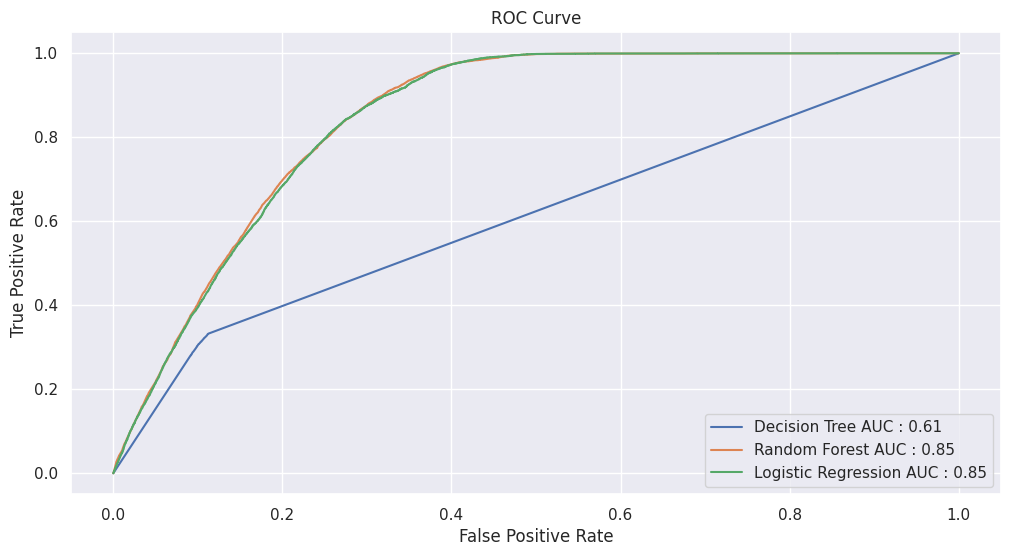

In [32]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve

def plot_roc(ax,
        datase_train,
        dataset_test,
        model,
        title
):
    x_train, y_train = datase_train
    x_test,  y_test  = dataset_test

    y_test_prob = model.predict_proba(x_test)[:,1]
    fpr, tpr, thresh = roc_curve(y_test, y_test_prob)

    auc = roc_auc_score(y_test, y_test_prob)
    ax.plot(fpr, tpr, label=f'{title} AUC : {auc:.2f}')

    ax.set_title('ROC Curve')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc=0)


def plot_precision_recall_curve(ax, 
                                dataset_train,
                                dataset_test,
                                model,
                                title : str):
    
    x_train, y_train = dataset_train
    x_test,  y_test  = dataset_test

    y_test_prob = model.predict_proba(x_test)[:,1]
    precision, recall, thresholds = precision_recall_curve(y_true = y_test,
    
                                                        probas_pred = y_test_prob)
    ax.plot(thresholds, precision[:-1], label=f'{title} - Precision')
    ax.plot(thresholds, recall[:-1], label=f'{title} - Recall')
    ax.set_title('Precision-Recall Curve')
    ax.set_xlabel('Thresholds')
    ax.set_ylabel('Precision/Recall')
    ax.legend(loc=0)

    return precision, recall, thresholds 


fig, ax = plt.subplots(1,1, figsize=(12,6))

plot_roc(ax,
    datase_train = (X_train_ros, y_train_ros),
    dataset_test  = (X_test, y_test),
    model = model,
    title = 'Decision Tree'
)

plot_roc(ax,
    datase_train = (X_train_ros, y_train_ros),
    dataset_test  = (X_test, y_test),
    model = rf,
    title = 'Random Forest'
)

plot_roc(ax,
    datase_train = (X_train_ros, y_train_ros),
    dataset_test  = (X_test, y_test),
    model = logistic_model,
    title = 'Logistic Regression'
)
    

(array([0.1225592, 0.1225793, 0.122976 , ..., 0.       , 0.       ,
        1.       ]),
 array([1., 1., 1., ..., 0., 0., 0.]),
 array([0.00756234, 0.00929575, 0.0105045 , ..., 0.75497898, 0.75622128,
        0.76715704]))

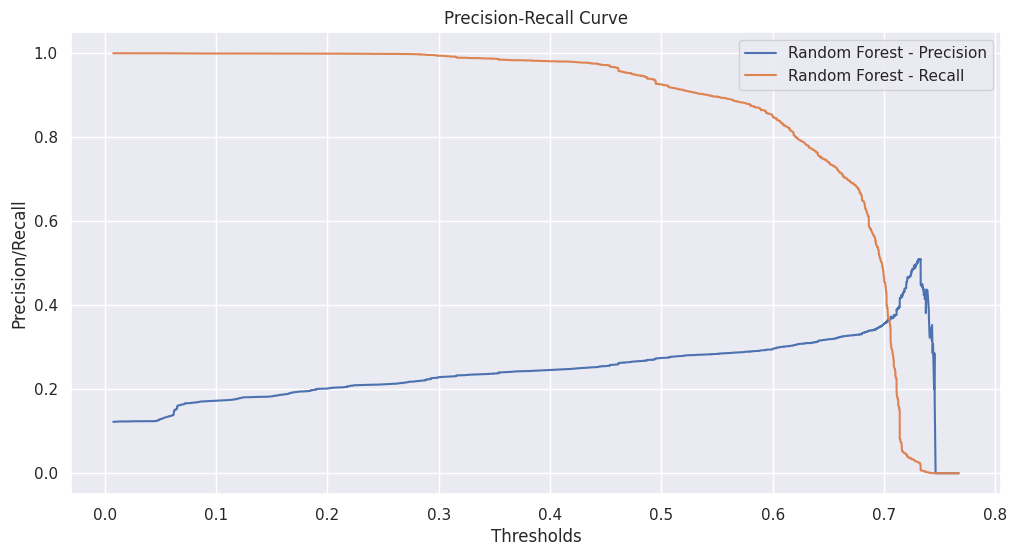

In [33]:

fig, ax = plt.subplots(1,1, figsize=(12,6))

plot_precision_recall_curve(ax,
    dataset_train = (X_train_ros, y_train_ros),
    dataset_test  = (X_test, y_test),
    model = rf,
    title = 'Random Forest'
)



(array([0.1225592 , 0.12256054, 0.12256188, ..., 0.        , 0.        ,
        1.        ]),
 array([1., 1., 1., ..., 0., 0., 0.]),
 array([0.00217737, 0.00220837, 0.00222521, ..., 0.89953823, 0.89971291,
        0.9036259 ]))

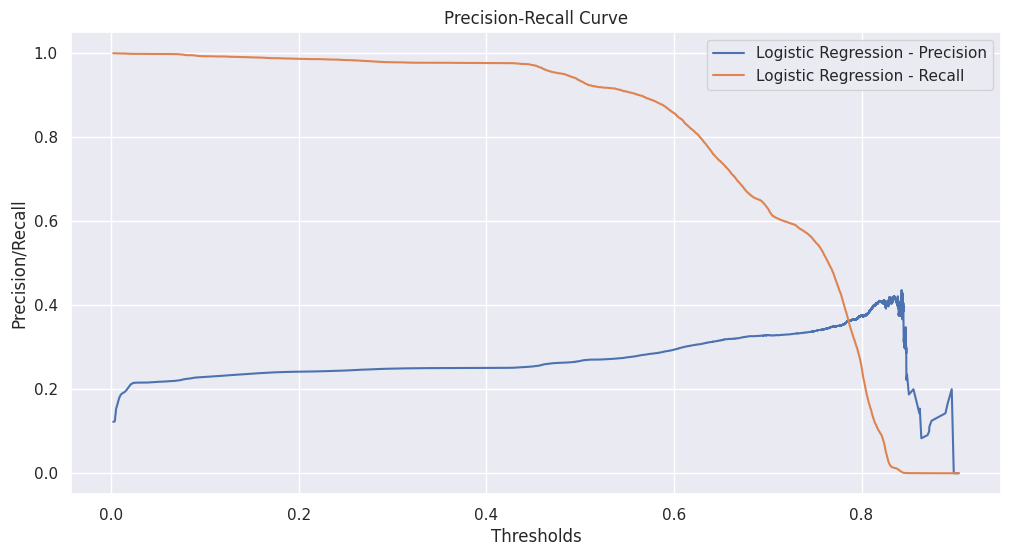

In [34]:
fig, ax = plt.subplots(1,1, figsize=(12,6))

plot_precision_recall_curve(ax,
    dataset_train = (X_train_ros, y_train_ros),
    dataset_test  = (X_test, y_test),
    model = logistic_model,
    title = 'Logistic Regression'
)

**Overfitting com random over sample**

##### 3.3.1.2 - SMOTE

In [35]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
y_train_smote.value_counts()

Response
0    200639
1    200639
Name: count, dtype: int64

In [36]:
rf_normal = RandomForestClassifier(criterion='entropy',
                            n_estimators=26,
                            max_depth=32,
                            n_jobs=-1)
rf_normal.fit(X = X_train,
          y = y_train)

RandomForestClassifier(criterion='entropy', max_depth=32, n_estimators=26,
                       n_jobs=-1)

In [67]:
rf = RandomForestClassifier(criterion='entropy',
                            n_estimators=26,
                            max_depth=16,
                            n_jobs=-1)
rf.fit(X = X_train_smote,
          y = y_train_smote)


RandomForestClassifier(criterion='entropy', max_depth=16, n_estimators=26,
                       n_jobs=-1)

In [68]:
metrics_rf = du.computeMetricsSklearnModel(model = rf_normal,
                              dataset_train = (X_train, y_train),
                              dataset_test  = (X_test, y_test),
                              dataset_valid =  (X_valid, y_valid))


metrics_rf = pd.DataFrame(metrics_rf)
metrics_rf['model'] = 'Random Forest'
metrics_rf

,accuracy,precision,recall,f1_score,auc,model
train,0.758070,0.330955,0.953365,0.491343,None,Random Forest
test,0.735705,0.298920,0.859590,0.443585,None,Random Forest
valid,0.735495,0.300088,0.869146,0.446139,None,Random Forest


In [69]:
metrics_rf = du.computeMetricsSklearnModel(model = rf,
                              dataset_train = (X_train_smote, y_train_smote),
                              dataset_test  = (X_test, y_test),
                              dataset_valid =  (X_valid, y_valid))


metrics_rf = pd.DataFrame(metrics_rf)
metrics_rf['model'] = 'Random Forest'
metrics_rf

,accuracy,precision,recall,f1_score,auc,model
train,0.854904,0.801286,0.943884,0.866759,None,Random Forest
test,0.766788,0.316629,0.779483,0.450331,None,Random Forest
valid,0.764358,0.313960,0.778432,0.447452,None,Random Forest


(array([0.1225592 , 0.1226088 , 0.12261148, ..., 0.33333333, 0.        ,
        1.        ]),
 array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
        5.35236396e-04, 0.00000000e+00, 0.00000000e+00]),
 array([0.00255287, 0.00260464, 0.0026098 , ..., 0.7763579 , 0.77778405,
        0.78703525]))

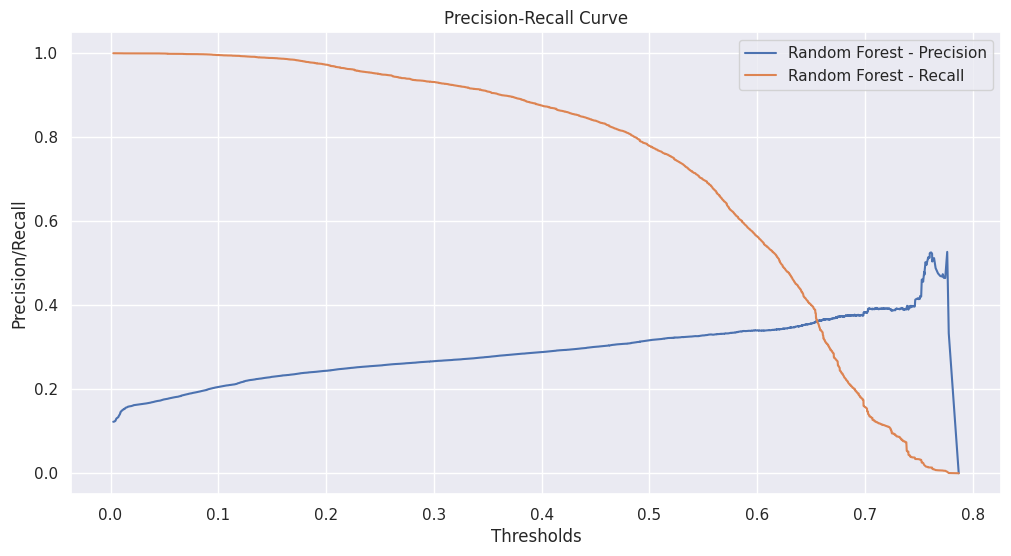

In [70]:

fig, ax = plt.subplots(1,1, figsize=(12,6))

plot_precision_recall_curve(ax,
    dataset_train = (X_train_smote, y_train_smote),
    dataset_test  = (X_test, y_test),
    model = rf,
    title = 'Random Forest'
)



#### 3.3.2 - UnderSampling

##### Random Under Sampling

**O Overfitting se mantem**

In [40]:
from imblearn.under_sampling import RandomUnderSampler
random_under = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = random_under.fit_resample(X_train, y_train)
y_train_under.value_counts()

Response
0    28026
1    28026
Name: count, dtype: int64

In [97]:
def run_battery_test(
        curr_dataset_train,
        dataset_test,
        dataset_valid
):
        X_train, y_train = curr_dataset_train
        X_test,  y_test  = dataset_test
        X_valid, y_valid = dataset_valid

        rf_model = RandomForestClassifier(criterion='gini',
                                n_estimators=100,
                                max_depth=48,
                                n_jobs=-1
                                ,class_weight='balanced',
                                max_features='log2',
                                bootstrap=True
                                ,max_samples=0.8
                                )
        rf_model.fit(X = X_train,
                y = y_train)

        dt_model = DecisionTreeClassifier(criterion='gini',
                                max_depth=16)
        dt_model.fit(X = X_train,
                y = y_train)

        logistic_model = LogisticRegression()
        logistic_model.fit(X = X_train,
                y = y_train) 

        metrics_rf = du.computeMetricsSklearnModel(model = rf_model,
                                dataset_train = (X_train, y_train),
                                dataset_test  = (X_test, y_test),
                                dataset_valid =  (X_valid, y_valid))


        metrics_rf = pd.DataFrame(metrics_rf)
        metrics_rf['model'] = 'Random Forest'

        metrics_dt = du.computeMetricsSklearnModel(model = dt_model,
                                dataset_train = (X_train, y_train),
                                dataset_test  = (X_test, y_test),
                                dataset_valid =  (X_valid, y_valid))
        metrics_dt = pd.DataFrame(metrics_dt)
        metrics_dt['model'] = 'Decision Tree'

        metrics_lr = du.computeMetricsSklearnModel(model = logistic_model,
                                dataset_train = (X_train, y_train),
                                dataset_test  = (X_test, y_test),
                                dataset_valid =  (X_valid, y_valid))
        metrics_lr = pd.DataFrame(metrics_lr)
        metrics_lr['model'] = 'Logistic Regression'

        metrics_all = pd.concat([metrics_rf, metrics_dt, metrics_lr], axis=0)
        metrics_all.sort_values(by=['f1_score'], ascending=False)

        return rf_model, dt_model, logistic_model, metrics_all




In [98]:
rf_normal, dt_normal, lr_normal, metrics_normal = run_battery_test(
    curr_dataset_train = (X_train, y_train),
    dataset_test  = (X_test, y_test),
    dataset_valid= (X_valid, y_valid)
)

metrics_normal.sort_values(by=['f1_score'], ascending=False)

/home/p123/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,accuracy,precision,recall,f1_score,auc,model
train,0.890079,0.528241,0.964747,0.682683,None,Random Forest
test,0.798504,0.321676,0.580910,0.414065,None,Random Forest
valid,0.797255,0.320429,0.583623,0.413715,None,Random Forest
train,0.886874,0.781723,0.106829,0.187971,None,Decision Tree
valid,0.871445,0.327668,0.046428,0.081331,None,Decision Tree
test,0.871909,0.334207,0.045495,0.080088,None,Decision Tree
train,0.877170,0.178947,0.000607,0.001209,None,Logistic Regression
valid,0.877316,0.266667,0.000535,0.001068,None,Logistic Regression
test,0.877047,0.071429,0.000268,0.000533,None,Logistic Regression


(array([0.1225592 , 0.12276187, 0.12277397, ..., 0.66666667, 0.        ,
        1.        ]),
 array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
        1.78412132e-04, 0.00000000e+00, 0.00000000e+00]),
 array([0.00000000e+00, 6.01641753e-06, 8.18815130e-06, ...,
        9.20590192e-01, 9.27898283e-01, 9.29633968e-01]))

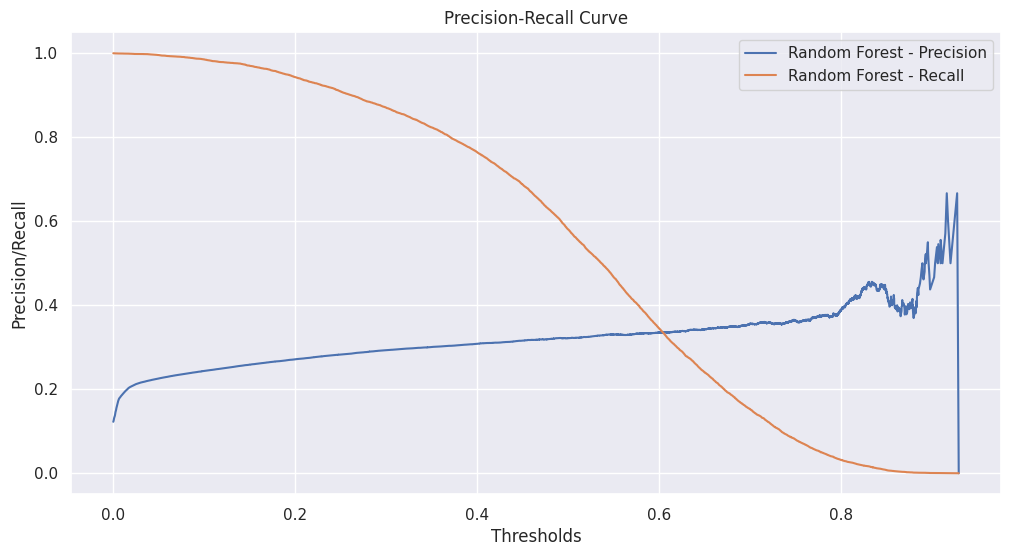

In [99]:

fig, ax = plt.subplots(1,1, figsize=(12,6))

plot_precision_recall_curve(ax,
    dataset_train = (X_train, X_train),
    dataset_test  = (X_test, y_test),
    model = rf_normal,
    title = 'Random Forest'
)



In [73]:
rf_under, dt_under, lr_under, metrics_under = run_battery_test(
    curr_dataset_train = (X_train_under, y_train_under),
    dataset_test  = (X_test, y_test),
    dataset_valid= (X_valid, y_valid)
)

metrics_under.sort_values(by=['f1_score'], ascending=False)

/home/p123/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,accuracy,precision,recall,f1_score,auc,model
train,0.845304,0.776682,0.969314,0.862372,None,Random Forest
train,0.831460,0.770146,0.944944,0.848637,None,Decision Tree
train,0.786716,0.725368,0.922822,0.812267,None,Logistic Regression
valid,0.698957,0.280239,0.928419,0.430526,None,Random Forest
test,0.700370,0.280554,0.923550,0.430371,None,Random Forest
valid,0.700056,0.277960,0.905807,0.425385,None,Decision Tree
test,0.700949,0.277871,0.900714,0.424717,None,Decision Tree
valid,0.685231,0.270915,0.927214,0.419314,None,Logistic Regression
test,0.685741,0.270701,0.923283,0.418655,None,Logistic Regression


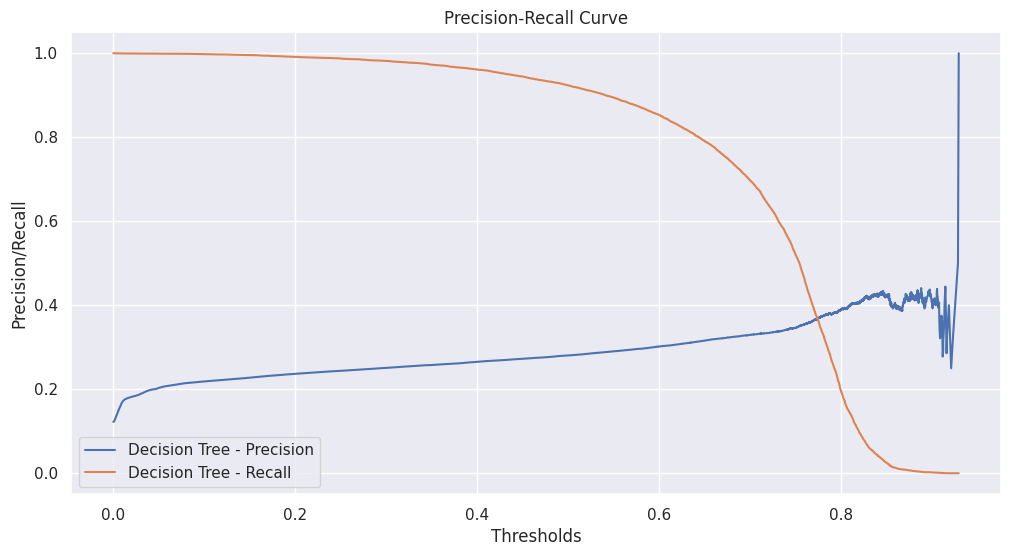

In [79]:
fig, ax = plt.subplots(1,1, figsize=(12,6))

content = plot_precision_recall_curve(ax,
    dataset_train = (X_train_under, y_train_under),
    dataset_test  = (X_test, y_test),
    model = rf_under,
    title = 'Decision Tree'
)

**Teste reduzindo o numero de features**

In [44]:
importances = pd.DataFrame({'feature': X_train_under.columns, 'importance': lr_under.coef_[0]})
importances.importance = importances.importance.abs()
select_cols_lr = importances[importances.importance >= importances.importance.quantile(0.8)].feature.tolist()
len(select_cols_lr)


44

In [45]:
importances_rf = pd.DataFrame({'feature': X_train_under.columns, 'importance': dt_under.feature_importances_})
select_cols_rf = importances_rf[importances_rf.importance >= importances_rf.importance.quantile(0.75)].feature.tolist()
len(select_cols_rf)



55

**Logistic**

In [80]:
rf_under, dt_under, lr_under, metrics_under = run_battery_test(
    curr_dataset_train = (X_train_under.loc[:,select_cols_lr], y_train_under),
    dataset_test  = (X_test.loc[:,select_cols_lr], y_test),
    dataset_valid= (X_valid.loc[:,select_cols_lr], y_valid)
)

metrics_under.sort_values(by=['f1_score'], ascending=False)


,accuracy,precision,recall,f1_score,auc,model
train,0.836812,0.774620,0.950046,0.853411,None,Random Forest
train,0.816420,0.758437,0.928602,0.834937,None,Decision Tree
train,0.798562,0.732360,0.941019,0.823680,None,Logistic Regression
test,0.706415,0.281967,0.902319,0.429667,None,Decision Tree
valid,0.703844,0.280858,0.907546,0.428964,None,Decision Tree
test,0.703267,0.279977,0.904193,0.427562,None,Random Forest
test,0.691470,0.276607,0.939429,0.427377,None,Logistic Regression
valid,0.689183,0.275547,0.942735,0.426449,None,Logistic Regression
valid,0.699990,0.277787,0.904870,0.425079,None,Random Forest


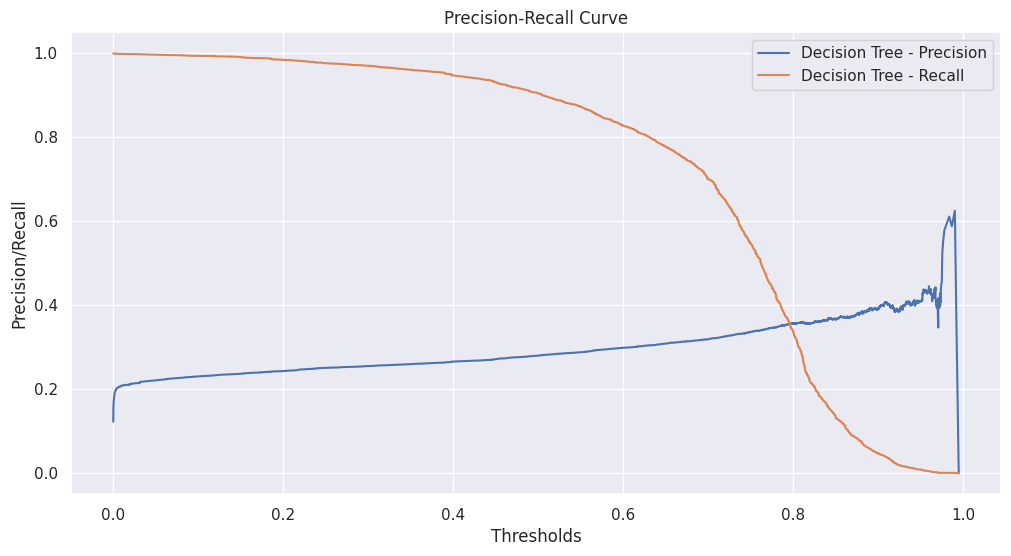

In [81]:
fig, ax = plt.subplots(1,1, figsize=(12,6))

content = plot_precision_recall_curve(ax,
    dataset_train = (X_train_under.loc[:,select_cols_lr], y_train_under),
    dataset_test  = (X_test.loc[:,select_cols_lr], y_test),
    model = rf_under,
    title = 'Decision Tree'
)

**Random Forest**

In [47]:


rf_under, dt_under, lr_under, metrics_under = run_battery_test(
    curr_dataset_train = (X_train_under.loc[:,select_cols_rf], y_train_under),
    dataset_test  = (X_test.loc[:,select_cols_rf], y_test),
    dataset_valid= (X_valid.loc[:,select_cols_rf], y_valid)
)

metrics_under.sort_values(by=['f1_score'], ascending=False)

/home/p123/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,accuracy,precision,recall,f1_score,auc,model
train,0.873564,0.808789,0.978449,0.885566,None,Random Forest
train,0.831692,0.769106,0.947977,0.849225,None,Decision Tree
train,0.787679,0.723704,0.930672,0.814241,None,Logistic Regression
test,0.705049,0.281558,0.906512,0.429665,None,Random Forest
valid,0.702073,0.279789,0.908884,0.427865,None,Random Forest
test,0.698686,0.276822,0.904550,0.423913,None,Decision Tree
valid,0.697005,0.276091,0.907546,0.423382,None,Decision Tree
valid,0.679770,0.268416,0.934573,0.417052,None,Logistic Regression
test,0.680876,0.268545,0.930419,0.416792,None,Logistic Regression


**O Overfitting se mantem**

#### 3.3.3 - Embeded model (estratégia propria)

A estratégia baseia-se em realizar diversos treinamentos, onde a cada novo treinamento havera um processo de amostratgem boostrap para a classe majoritaria e minoritaria, porém este processo sera realizado em um dataset equilibrado. 

**Exemplo:**

5k amostras classe 1 vs 100k amostras classe 2. 

* Cria-se um dateset, que recebe todas as amostras da classe 1, e uma amostragem aleatória da classe 2, contendo 5k elementos. 
* Realiza-se o treinamento com este subset (que pode receber 5k c1 e os 5k c2 ou, 3k c1 (amostragem por bootstrap) e 3kc2 (subamostragem por bootstrap)). 
* Cada contribui com a probabilidade do elemento pertecenter a uma das classes. 
* O resultado é dado pela média de probabilidades. 
    

In [48]:
from sklearn.tree import DecisionTreeClassifier
df_to_model = df_3_encoded.copy()
df_to_model_train, df_to_model_test = train_test_split(df_to_model, test_size=0.3, 
                                                       random_state=42, stratify=df_to_model['Response'])

inference_cols = [x for x in df_to_model.columns if x not in ('Response','Gender')]
model = DecisionTreeClassifier(criterion='entropy',)
model.fit(X = df_to_model_train.loc[:, inference_cols],
          y = df_to_model_train['Response'])


DecisionTreeClassifier(criterion='entropy')

In [49]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression()
logistic_model.fit(X = df_to_model_train.loc[:, inference_cols],
                     y = df_to_model_train['Response']) 

/home/p123/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [50]:
y_pred = logistic_model.predict_proba(df_to_model_test.loc[:, inference_cols])
y_pred

array([[0.9969883 , 0.0030117 ],
       [0.86156091, 0.13843909],
       [0.99850084, 0.00149916],
       ...,
       [0.79947649, 0.20052351],
       [0.99772313, 0.00227687],
       [0.95013694, 0.04986306]])

In [51]:
def custom_predict(model,
                   data,
                   threshold=0.5):
    
    y_hat = model.predict_proba(data)

    return (y_hat[:, 1] > threshold).astype(int)

In [52]:
logistic_model.predict_proba(df_to_model_test.loc[:, inference_cols])

array([[0.9969883 , 0.0030117 ],
       [0.86156091, 0.13843909],
       [0.99850084, 0.00149916],
       ...,
       [0.79947649, 0.20052351],
       [0.99772313, 0.00227687],
       [0.95013694, 0.04986306]])

In [53]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score , confusion_matrix

y_pred = custom_predict(model = model,
                        data = df_to_model_test.loc[:, inference_cols])

accuracy = accuracy_score(df_to_model_test['Response'],     y_pred=y_pred)
f1_score = f1_score(df_to_model_test['Response'],           y_pred=y_pred)
precision = precision_score(df_to_model_test['Response'],   y_pred=y_pred)
recall = recall_score(df_to_model_test['Response'],         y_pred=y_pred)

confusion_matrix = confusion_matrix(df_to_model_test['Response'], y_pred=y_pred)

print(f'Accuracy: {accuracy:.4f} | F1 Score: {f1_score:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}')

Accuracy: 0.8262 | F1 Score: 0.2984 | Precision: 0.2953 | Recall: 0.3016


In [54]:
confusion_matrix

array([[90234, 10086],
       [ 9787,  4226]])

In [55]:
df_to_model.Response.value_counts()

Response
0    334399
1     46710
Name: count, dtype: int64

In [56]:
importancies = model.feature_importances_
importancies = dict(zip(inference_cols , model.feature_importances_))
df_importancies = pd.DataFrame(importancies,
             index = [0]).T

df_importancies.columns = ['score']
df_importancies = df_importancies.reset_index(drop = False)
df_importancies = df_importancies.rename(columns={'0' : 'socre'})
df_importancies = df_importancies.sort_values(by = 'score',
                                              ascending=False)


df_importancies.reset_index()


,level_0,index,score
0,3,Previously_Insured,0.213793
1,0,id,0.187259
2,7,Vintage,0.160310
3,6,Annual_Premium,0.153049
4,1,Age,0.062827
5,5,Vehicle_Damage,0.026603
6,9,entre_30_50,0.017789
7,218,sexo_feminino,0.015589
8,193,region_code_28.0,0.009231
9,129,policy_sales_channel_124.0,0.007431


In [57]:
model.feature_importances_

array([1.87259270e-01, 6.28269236e-02, 3.74954700e-04, 2.13793109e-01,
       7.26111863e-03, 2.66025237e-02, 1.53048667e-01, 1.60309538e-01,
       3.59515768e-03, 1.77885548e-02, 2.20949382e-04, 3.02629879e-05,
       6.87939745e-04, 5.03919412e-04, 0.00000000e+00, 4.54978637e-04,
       5.21859331e-04, 3.89159757e-05, 2.17502475e-04, 5.03222184e-04,
       2.85337650e-04, 1.13554934e-03, 2.58198091e-04, 2.80202505e-04,
       2.49052107e-04, 0.00000000e+00, 0.00000000e+00, 1.28157798e-04,
       2.88860781e-05, 7.45554544e-05, 5.16061919e-05, 3.16523264e-04,
       5.60965556e-04, 1.32199375e-03, 3.85148944e-03, 0.00000000e+00,
       0.00000000e+00, 2.68760242e-04, 6.26535541e-04, 5.30197284e-04,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 6.26692383e-05,
       8.70479660e-05, 1.28396888e-04, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 3.02949157e-05, 0.00000000e+00,
       3.97732789e-05, 2.18492237e-05, 0.00000000e+00, 6.36561107e-05,
      

# 4 - Treinamento dos modelos

In [58]:
# trbalhar com as colunas abaixo
# Age, 
# Vehichle_Age
# Annual Premium 
# vintage, 
# Response